# Điều chỉnh phần data processing

### Xử lý missing values và outliers

Dưới đây xử lý dữ liệu thiếu và giá trị ngoại lai cho `df_train`:

In [110]:
# 2. Phát hiện và xử lý Outliers (phương pháp IQR)

def detect_outliers_iqr(df, cols, factor=1.5):
    """Đánh dấu outliers: |x - median| > factor * IQR."""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        mask |= (df[col] < lower) | (df[col] > upper)
    return mask

# 2.1 Xử lý outlier cho 'length' bằng IQR
numeric_cols = ["length"]
outlier_mask = detect_outliers_iqr(df_train_clean, numeric_cols)
df_train_clean = df_train_clean[~outlier_mask].reset_index(drop=True)
print(f"Sau khi lọc ngoại lai chiều dài (IQR): {len(df_train_clean):,} dòng (Đã xóa {n_before - len(df_train_clean):,} dòng)")

# 2.2 Lọc nhiễu tọa độ GPS bằng Bounding Box của TP.HCM
n_before_bbox = len(df_train_clean)
valid_bbox = (
    (df_train_clean['lat_snode'] >= 10.3) & (df_train_clean['lat_snode'] <= 10.9) &
    (df_train_clean['long_snode'] >= 106.3) & (df_train_clean['long_snode'] <= 106.9)
)
df_train_clean = df_train_clean[valid_bbox].reset_index(drop=True)
print(f"Sau khi lọc nhiễu tọa độ GPS (Bounding Box): {len(df_train_clean):,} dòng (Đã xóa {n_before_bbox - len(df_train_clean):,} dòng nhiễu)")

Sau khi lọc ngoại lai chiều dài (IQR): 30,872 dòng (Đã xóa 2,569 dòng)
Sau khi lọc nhiễu tọa độ GPS (Bounding Box): 30,872 dòng (Đã xóa 0 dòng nhiễu)


### Thêm biến is_weekend

/tmp/ipykernel_6121/3686716984.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.





 Phân bổ dữ liệu theo bối cảnh (Ngày thường vs Cuối tuần):
is_weekend
False    20291
True     11230
Name: count, dtype: int64


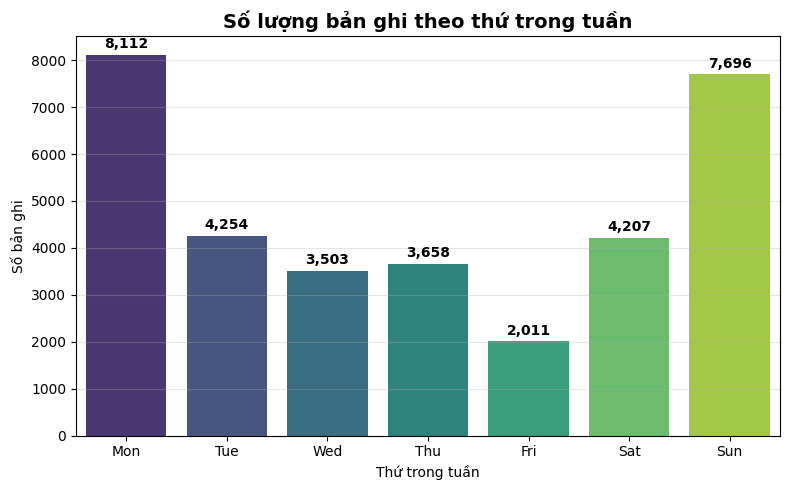

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df đã có cột weekday (0=Mon … 6=Sun)
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

#Thêm biến phân loại ngày cuối tuần
df_train_clean['is_weekend'] = df_train_clean['weekday'].isin([5, 6])
print("\n Phân bổ dữ liệu theo bối cảnh (Ngày thường vs Cuối tuần):")
print(df_train_clean['is_weekend'].value_counts())

# Thống kê số lượng bản ghi theo weekday
weekday_counts = (
    df["weekday"]
    .value_counts()
    .sort_index()
    .rename_axis("weekday_num")
    .rename("count")
    .reset_index()
)
weekday_counts["weekday_name"] = weekday_counts["weekday_num"].map(weekday_map)

# --- Vẽ biểu đồ cột ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_counts,
    x="weekday_name",
    y="count",
    palette="viridis"
)

# Thêm nhãn và giá trị
plt.title("Số lượng bản ghi theo thứ trong tuần", fontsize=14, weight='bold')
plt.xlabel("Thứ trong tuần")
plt.ylabel("Số bản ghi")
plt.grid(axis="y", alpha=0.3)

# Gắn số lên đầu mỗi cột
for index, row in weekday_counts.iterrows():
    plt.text(index, row["count"] + weekday_counts["count"].max() * 0.01,
             f"{row['count']:,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()